In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
auto_analyse_address = 'full_run_260428.csv'
auto_analyse_df = pd.read_csv(auto_analyse_address)

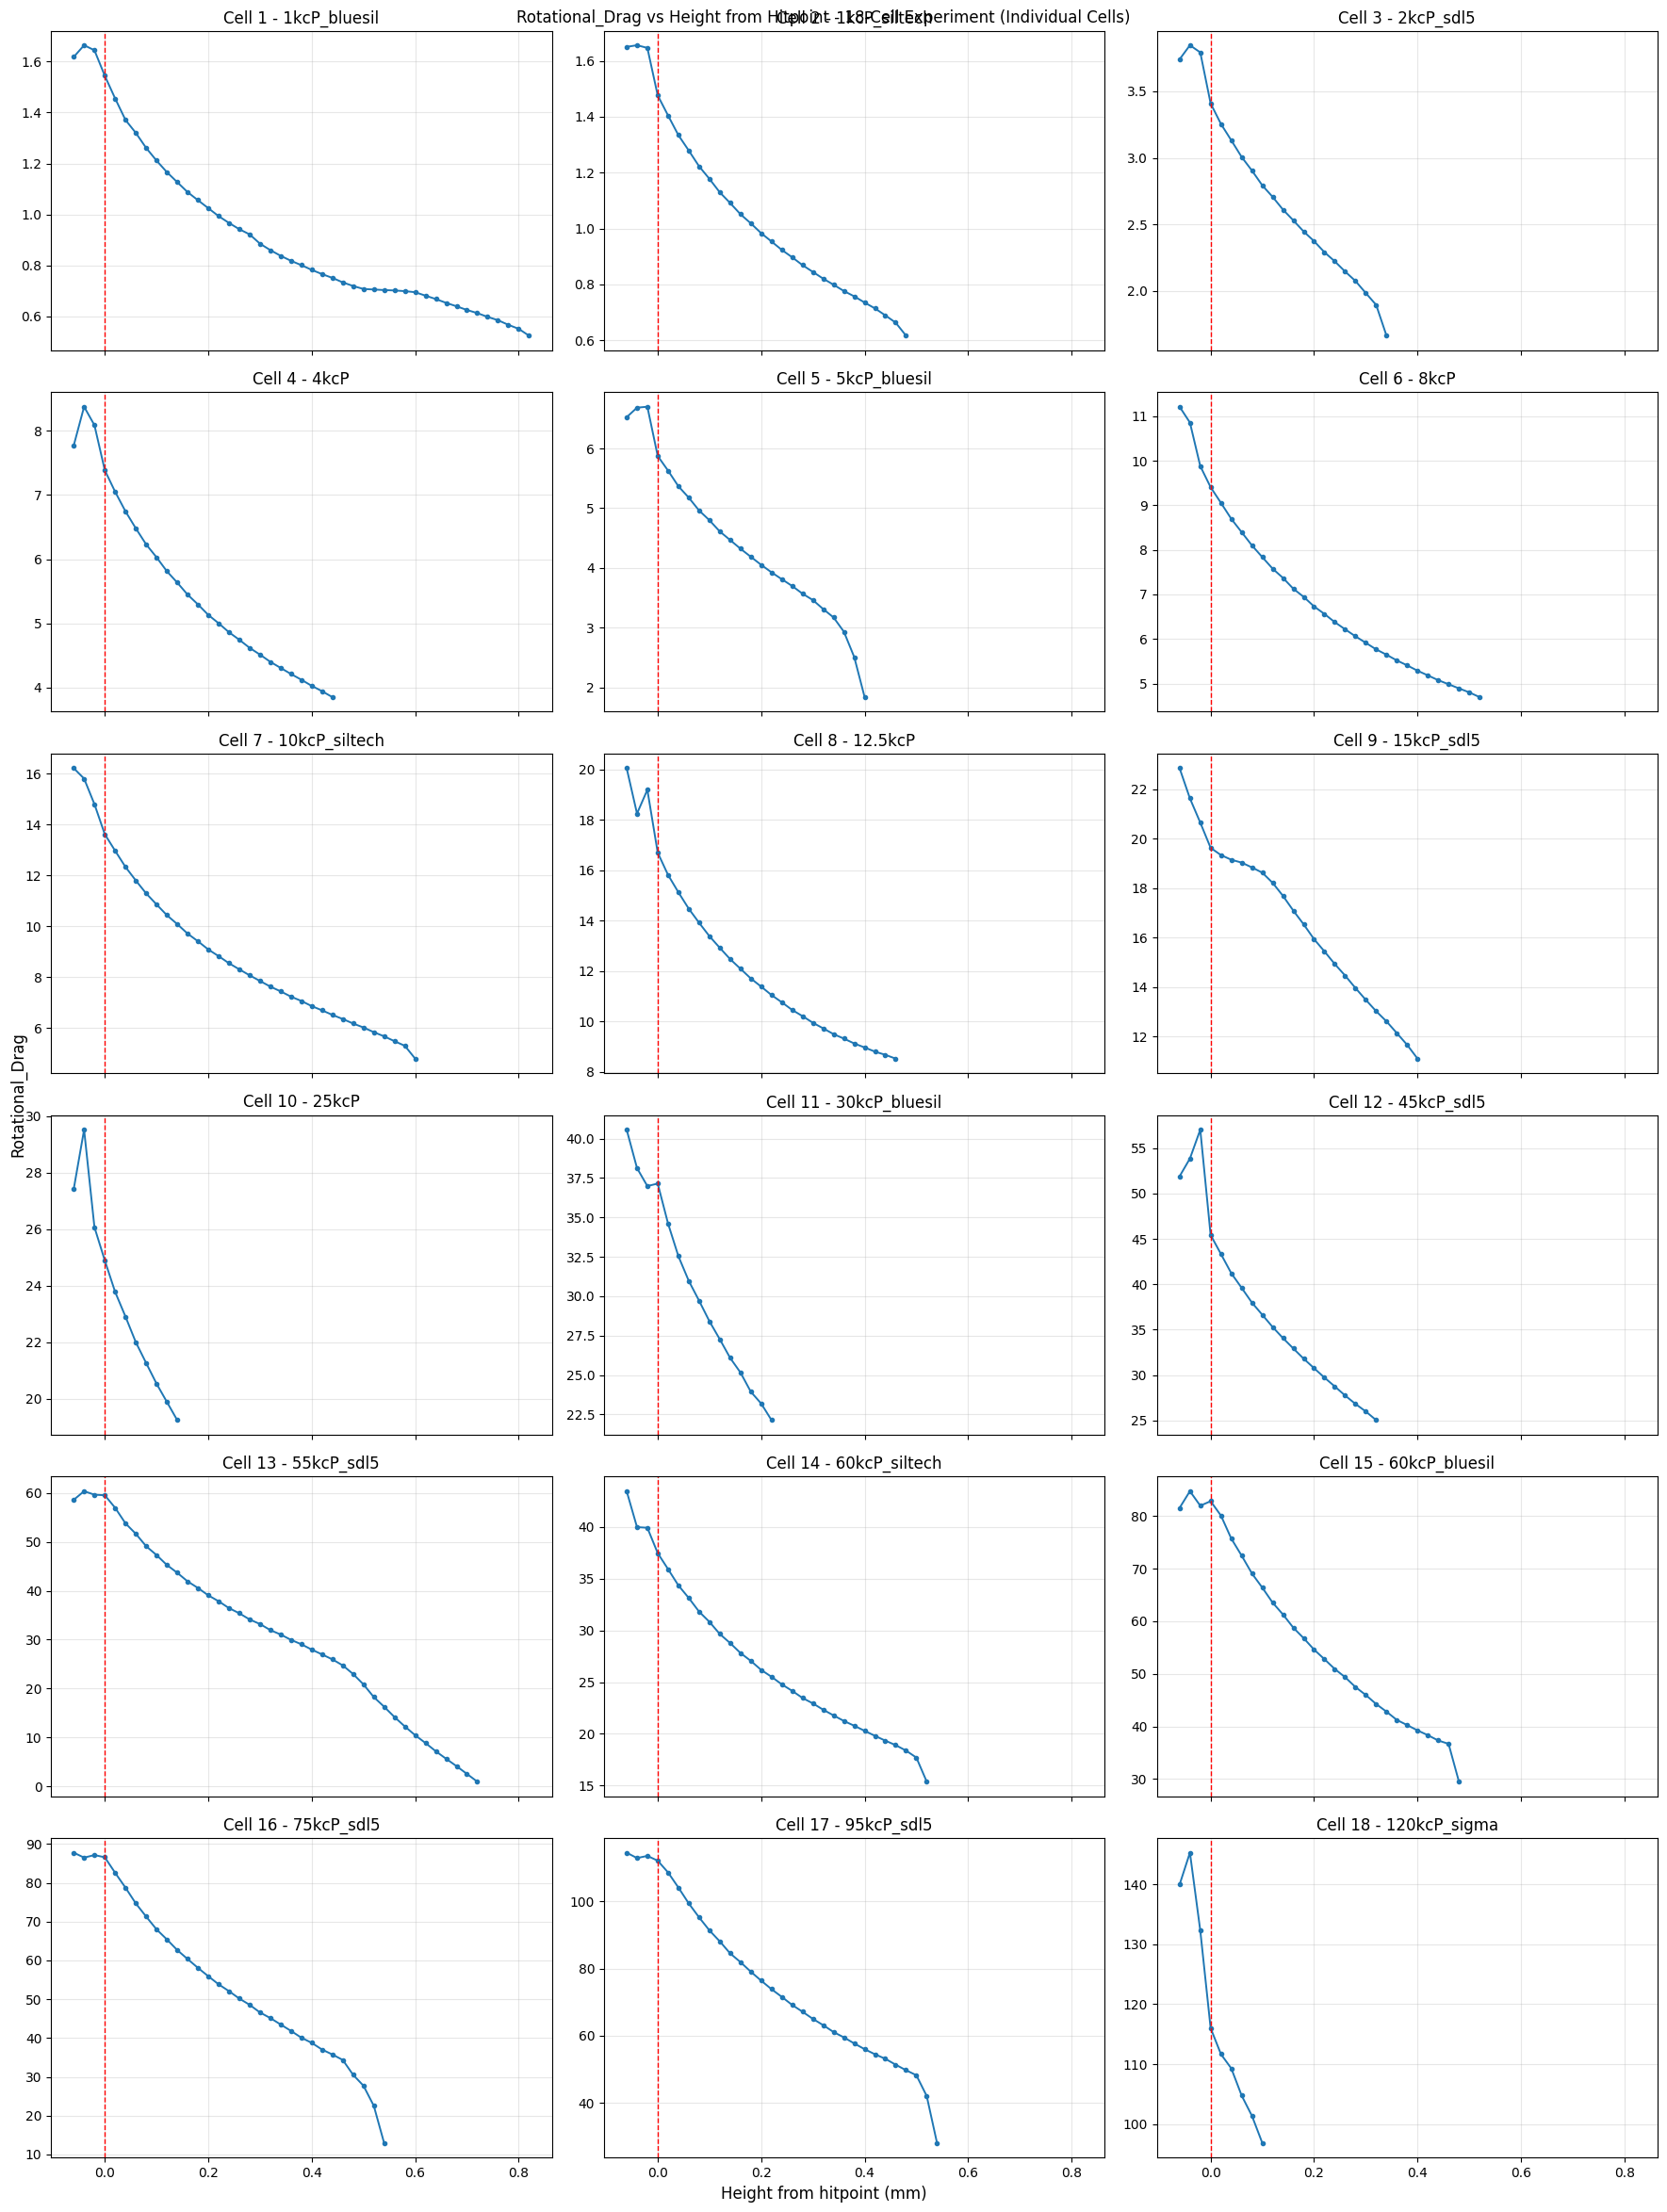

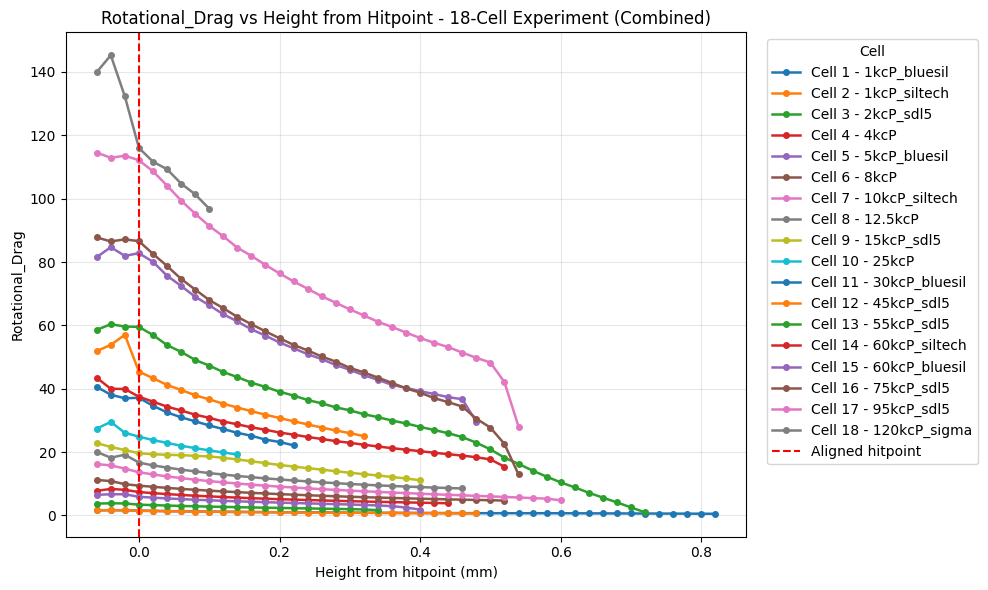

In [21]:
# Rotational_Drag vs height-from-hitpoint for the 18-cell experiment
# Individual cell plots first, then the combined overlay
plot_df = auto_analyse_df.copy()
if 'Z_Height_mm' not in plot_df.columns and 'Z_Hegiht_mm' in plot_df.columns:
    plot_df = plot_df.rename(columns={'Z_Hegiht_mm': 'Z_Height_mm'})

required_cols = {'cell', 'Z_Height_mm', 'Rotational_Drag'}
missing = required_cols - set(plot_df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df.columns)}")

label_col = 'Cell_Label' if 'Cell_Label' in plot_df.columns else None
cols_to_keep = ['cell', 'Z_Height_mm', 'Rotational_Drag'] + ([label_col] if label_col else [])
plot_df = plot_df[cols_to_keep].dropna(subset=['cell', 'Z_Height_mm', 'Rotational_Drag'])

cell_ids = sorted(plot_df['cell'].dropna().unique().tolist())
if not cell_ids:
    raise ValueError('No cell data available to plot.')

n_cells = len(cell_ids)
ncols = min(3, n_cells)
nrows = int(np.ceil(n_cells / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, cell_id in zip(axes, cell_ids):
    cell_df = plot_df[plot_df['cell'] == cell_id].sort_values('Z_Height_mm').reset_index(drop=True)

    if len(cell_df) < 4:
        ax.text(0.5, 0.5, f'Skipping Cell {int(cell_id)}\nneed >=4 points', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    cell_label = ''
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    hit_idx = 3
    hit_z = cell_df.loc[hit_idx, 'Z_Height_mm']
    x_from_hit_mm = cell_df['Z_Height_mm'] - hit_z

    ax.plot(
        x_from_hit_mm,
        cell_df['Rotational_Drag'],
        marker='o',
        linewidth=1.4,
        markersize=3
    )
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.0)
    title_suffix = f' - {cell_label}' if cell_label else ''
    ax.set_title(f'Cell {int(cell_id)}{title_suffix}')
    ax.grid(True, alpha=0.3)

for ax in axes[n_cells:]:
    ax.set_visible(False)

fig.supxlabel('Height from hitpoint (mm)')
fig.supylabel('Rotational_Drag')
fig.suptitle('Rotational_Drag vs Height from Hitpoint - 18-Cell Experiment (Individual Cells)')
fig.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for cell_id, cell_df in plot_df.groupby('cell'):
    cell_df = cell_df.sort_values('Z_Height_mm').reset_index(drop=True)

    if len(cell_df) < 4:
        print(f"Skipping Cell {int(cell_id)}: need >=4 points to define hitpoint, found {len(cell_df)}")
        continue

    hit_idx = 3
    hit_z = cell_df.loc[hit_idx, 'Z_Height_mm']
    x_from_hit_mm = cell_df['Z_Height_mm'] - hit_z

    cell_label = ''
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    legend_label = f"Cell {int(cell_id)} - {cell_label}" if cell_label else f"Cell {int(cell_id)}"

    plt.plot(
        x_from_hit_mm,
        cell_df['Rotational_Drag'],
        marker='o',
        linewidth=1.8,
        markersize=4,
        label=legend_label
    )

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Aligned hitpoint')

plt.xlabel('Height from hitpoint (mm)')
plt.ylabel('Rotational_Drag')
plt.title('Rotational_Drag vs Height from Hitpoint - 18-Cell Experiment (Combined)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cell', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

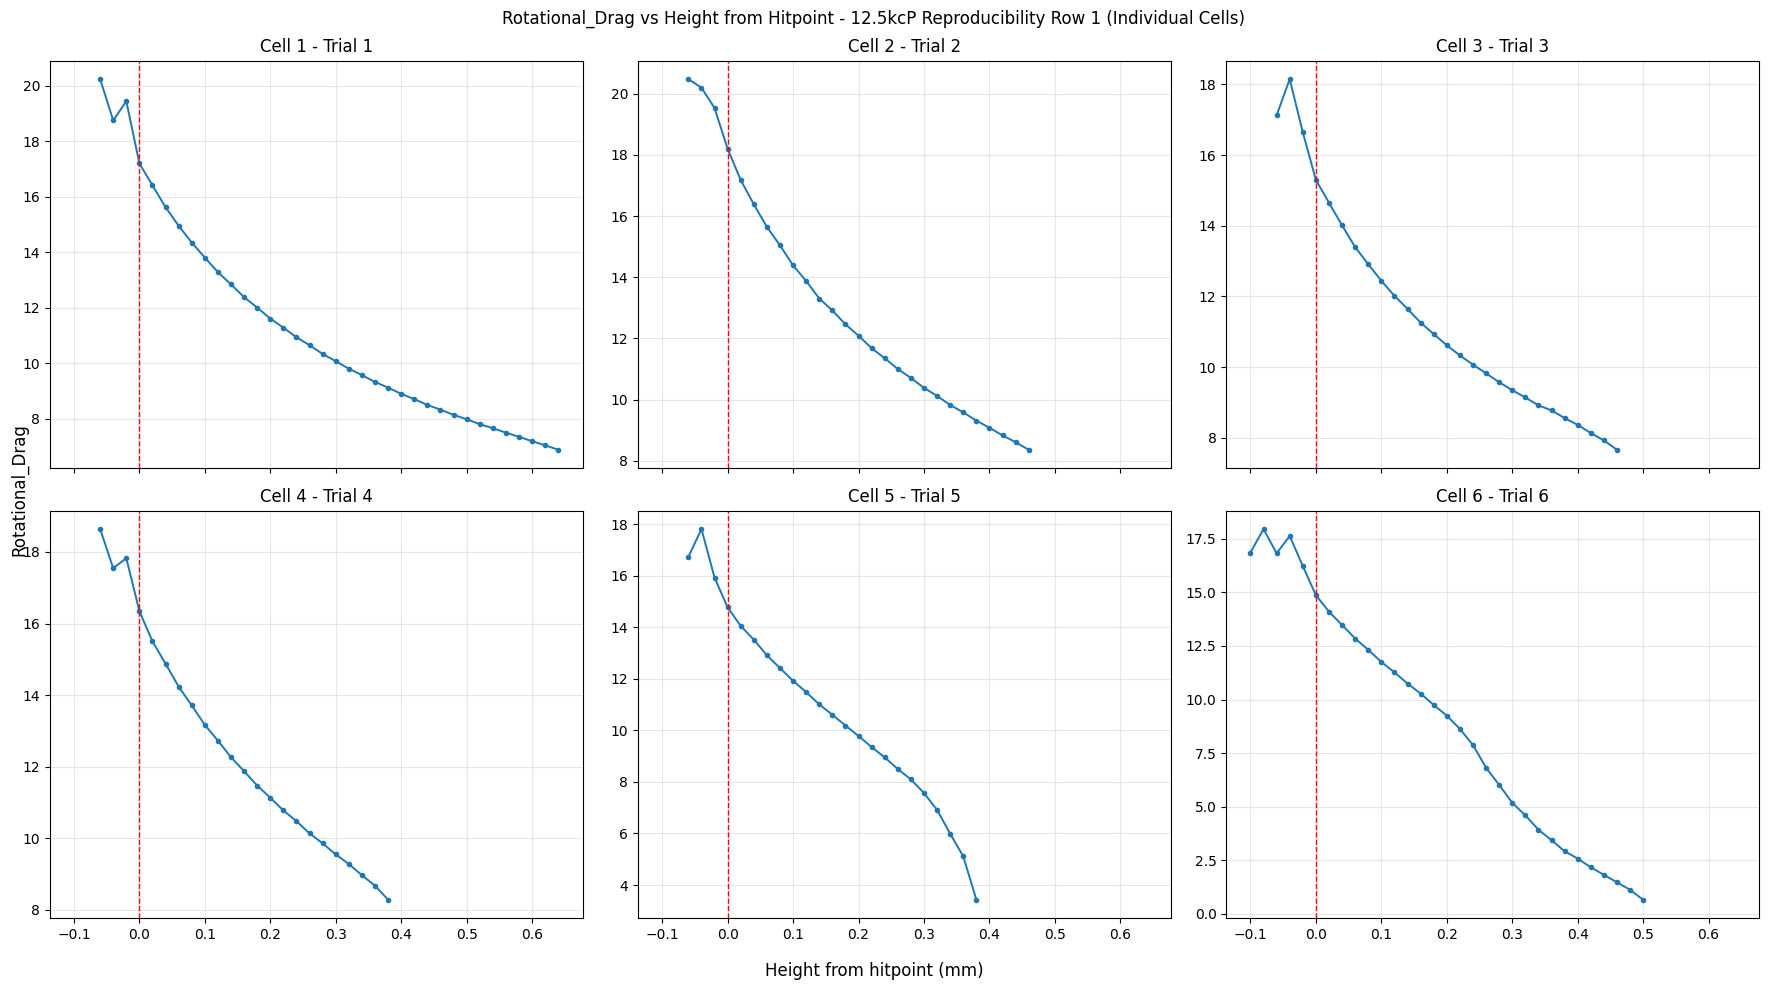

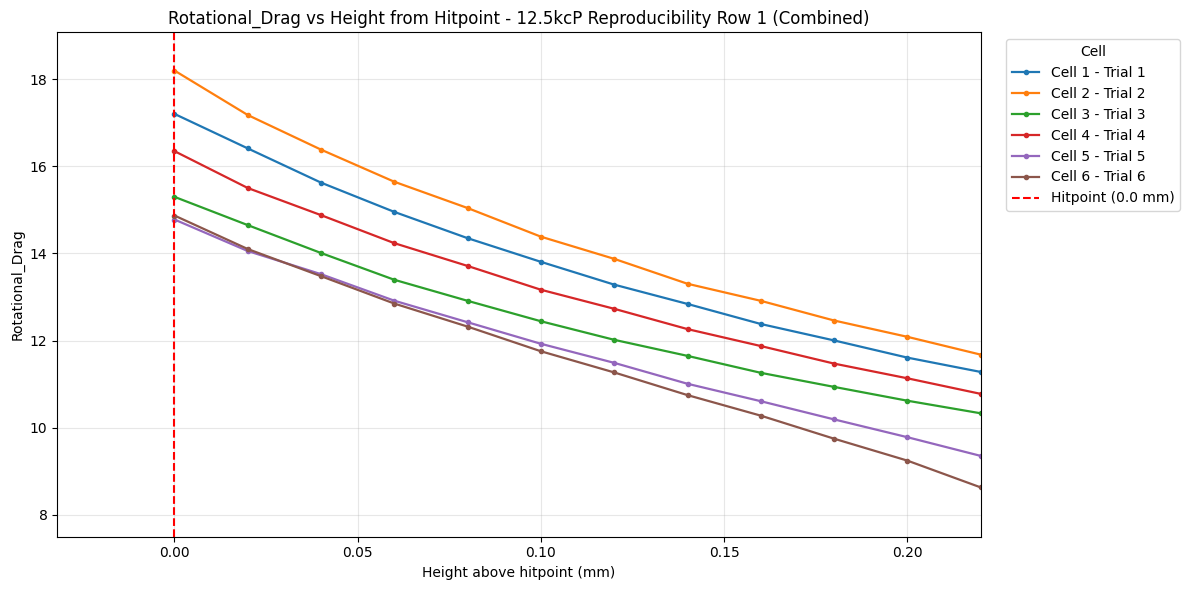

In [23]:
# Load the dynamic analysis data
dynamic_analyse_address = r"C:\Users\ianng\OneDrive - University of Toronto\Documents\GitHub\visc_automated_workflow_V3\results\Auto-runs\dynamic_analysis_12_5kcP_Reproducibility_Brush_custom_20260506_114319.csv"
dynamic_analyse_df = pd.read_csv(dynamic_analyse_address, encoding='cp1252', skiprows=10)

# Prepare the data for per-cell plots
plot_df_dynamic = dynamic_analyse_df.copy()
if 'Z_Height_mm' not in plot_df_dynamic.columns and 'Z_Hegiht_mm' in plot_df_dynamic.columns:
    plot_df_dynamic = plot_df_dynamic.rename(columns={'Z_Hegiht_mm': 'Z_Height_mm'})

required_cols = {'cell', 'Z_Height_mm', 'Rotational_Drag'}
missing = required_cols - set(plot_df_dynamic.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df_dynamic.columns)}")

label_col = 'Cell_Label' if 'Cell_Label' in plot_df_dynamic.columns else None
cols_to_keep = ['cell', 'Z_Height_mm', 'Rotational_Drag'] + ([label_col] if label_col else [])
plot_df_dynamic = plot_df_dynamic[cols_to_keep].dropna(subset=['cell', 'Z_Height_mm', 'Rotational_Drag'])

cell_ids = sorted(plot_df_dynamic['cell'].dropna().unique().tolist())
if not cell_ids:
    raise ValueError('No cell data available to plot.')

plot_title_base = 'Rotational_Drag vs Height from Hitpoint - 12.5kcP Reproducibility Row 1'

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, cell_id in zip(axes, cell_ids):
    cell_df = plot_df_dynamic[plot_df_dynamic['cell'] == cell_id].sort_values('Z_Height_mm').reset_index(drop=True)

    if len(cell_df) < 4:
        ax.text(0.5, 0.5, f'Skipping Cell {int(cell_id)}\nneed >=4 points', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    cell_label = ''
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    hit_idx = 3
    if int(cell_id) == 6 and cell_label == 'Trial 6':
        hit_idx = min(len(cell_df) - 1, hit_idx + 2)
    hit_z = cell_df.loc[hit_idx, 'Z_Height_mm']
    x_from_hit_mm = cell_df['Z_Height_mm'] - hit_z

    ax.plot(
        x_from_hit_mm,
        cell_df['Rotational_Drag'],
        marker='o',
        linewidth=1.4,
        markersize=3
    )
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.0)
    title_suffix = f' - {cell_label}' if cell_label else ''
    ax.set_title(f'Cell {int(cell_id)}{title_suffix}')
    ax.grid(True, alpha=0.3)

for ax in axes[len(cell_ids):]:
    ax.set_visible(False)

fig.supxlabel('Height from hitpoint (mm)')
fig.supylabel('Rotational_Drag')
fig.suptitle(f'{plot_title_base} (Individual Cells)')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))

for cell_id in cell_ids:
    cell_df = plot_df_dynamic[plot_df_dynamic['cell'] == cell_id].sort_values('Z_Height_mm').reset_index(drop=True)

    if len(cell_df) < 4:
        print(f"Skipping Cell {int(cell_id)}: need >=4 points to define hitpoint, found {len(cell_df)}")
        continue

    cell_label = ''
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    hit_idx = 3
    if int(cell_id) == 6 and cell_label == 'Trial 6':
        hit_idx = min(len(cell_df) - 1, hit_idx + 2)
    hit_z = cell_df.loc[hit_idx, 'Z_Height_mm']
    x_from_hit_mm = cell_df['Z_Height_mm'] - hit_z

    # Filter to only include points at or after the hitpoint
    plot_mask = x_from_hit_mm >= 0.0
    x_plot = x_from_hit_mm[plot_mask]
    y_plot = cell_df.loc[plot_mask, 'Rotational_Drag']

    legend_label = f"Cell {int(cell_id)} - {cell_label}" if cell_label else f"Cell {int(cell_id)}"
    
    ax.plot(
        x_plot,
        y_plot,
        marker='o',
        linewidth=1.6,
        markersize=3,
        label=legend_label
    )

# Aligned hitpoint marker
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Hitpoint (0.0 mm)')

ax.set_xlabel('Height above hitpoint (mm)')
ax.set_ylabel('Rotational_Drag')
ax.set_title(f'{plot_title_base} (Combined)')
ax.set_xlim(right=0.22)
ax.set_ylim(bottom=7.5)
ax.grid(True, alpha=0.3)
ax.legend(title='Cell', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()